# OPN (Omission Probability Network) 完整训练流程

> **目标**: 训练一个神经网络，输入 DDM 参数和 deadline，输出 omission 概率。
>
> **参考文献**: Leng, X., Fengler, A., Shenhav, A., & Frank, M. J. (2025). The Perils of Omitting Omissions when Modeling Evidence Accumulation.
>
> **OPN 输入**: `(drift_rate v, boundary a, nondecision_time t0, relative_starting_point zr, deadline d)`
>
> **OPN 输出**: `omission_probability (0-1)`

---
## 工作流概览
```
Step 1: 环境设置与路径配置
Step 2: DDM 批量仿真器
Step 3: 从参数先验生成训练数据
Step 4: 数据划分与标准化
Step 5: 构建并训练 OPN (MLP)
Step 6: 评估模型性能
Step 7: 可视化诊断
Step 8: 保存模型供后续 PyMC 使用
```
> 默认使用快速模式 (5000 组参数, ~30 min)。改为 `TRAIN_MODE = "full"` 可完整训练。

---
## Step 1: 环境设置

In [1]:
import sys, time, json, pickle, logging
from pathlib import Path
from datetime import datetime
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("OPN")

BASE_DIR = Path.cwd()
for _ in range(5):
    if (BASE_DIR / "1_Code").exists():
        break
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "2_Data" / "Generate_Data" / "OPN_Training"
FIG_DIR  = BASE_DIR / "3_Figures" / "OPN_Training"
for d in [DATA_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {BASE_DIR}")
print(f"Data dir:     {DATA_DIR}")
print(f"Figure dir:   {FIG_DIR}")
print(f"Python:       {sys.version}")

Project root: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
Data dir:     d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\OPN_Training
Figure dir:   d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\OPN_Training
Python:       3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [2]:
# Check numba (optional but recommended ~10-50x speedup)
HAS_NUMBA = False
try:
    from numba import njit
    HAS_NUMBA = True
    print("Numba available - will use JIT acceleration")
except ImportError:
    print("Numba not installed - using pure NumPy (slower)")
    print("Install: pip install numba")

import sklearn
print(f"scikit-learn {sklearn.__version__}")
print(f"numpy {np.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")

Numba not installed - using pure NumPy (slower)
Install: pip install numba
scikit-learn 1.6.1
numpy 2.2.0
matplotlib 3.10.0


### Training configuration (adjust here)

In [3]:
# TRAIN_MODE: "fast" = 5000 pairs (~30 min) | "full" = 50000 pairs (~5-8 h)
TRAIN_MODE = "fast"

PRIOR_RANGES = {
    "v":        (-5.0, 5.0),
    "a":        (0.2, 3.0),
    "t":        (0.1, 0.7),
    "z":        (0.0, 1.0),
    "deadline": (0.3, 2.5),
}

N_SIM_PER_SAMPLE = 5000
N_FAST_SAMPLES    = 5000
N_FULL_SAMPLES    = 50000

HIDDEN_LAYERS = (128, 64, 32)
MAX_ITER      = 500
ALPHA         = 0.001
TEST_SIZE     = 0.2
SEED          = 42

n_samples = N_FAST_SAMPLES if TRAIN_MODE == "fast" else N_FULL_SAMPLES
est_hrs = n_samples * N_SIM_PER_SAMPLE / 5000 / 3600
print(f"Mode: {TRAIN_MODE} ({n_samples} pairs, est {est_hrs:.1f}h)")
print(f"Network: {HIDDEN_LAYERS}")

Mode: fast (5000 pairs, est 1.4h)
Network: (128, 64, 32)


---
## Step 2: DDM Batch Simulator

Runs N Euler-Maruyama DDM trials for one parameter set, returns omission count.
Key: `decision_budget = deadline_s - t0`. If evidence never hits either boundary within this time, it is an omission.

In [4]:
def simulate_ddm_batch(v: float, a: float, z: float, t0: float,
                       deadline_s: float, n_trials: int = 5000, dt: float = 0.001) -> int:
    d_budget = deadline_s - t0
    if d_budget <= dt:
        return n_trials
    max_steps = int(d_budget / dt)
    x = np.full(n_trials, z, dtype=np.float64)
    active = np.ones(n_trials, dtype=bool)
    omission = np.ones(n_trials, dtype=bool)
    for _step in range(max_steps):
        if not active.any():
            break
        n_active = active.sum()
        noise = np.random.randn(n_active)
        dx = v * dt + np.sqrt(dt) * noise
        x[active] += dx
        hit_upper = (x >= a) & active
        if hit_upper.any():
            omission[hit_upper] = False
            active[hit_upper] = False
        hit_lower = (x <= 0.0) & active
        if hit_lower.any():
            omission[hit_lower] = False
            active[hit_lower] = False
    return int(omission.sum())

# Numba JIT version if available
if HAS_NUMBA:
    @njit
    def _sim_numba(v, a, z, max_steps, n_trials, dt):
        x = np.full(n_trials, float(z))
        active = np.ones(n_trials, dtype=np.bool_)
        om_count = 0
        sqrt_dt = np.sqrt(float(dt))
        v_f, a_f = float(v), float(a)
        for _step in range(max_steps):
            n_active = int(active.sum())
            if n_active == 0:
                break
            noise = np.random.randn(n_active)
            idx = 0
            for i in range(n_trials):
                if not active[i]:
                    continue
                x[i] += v_f * dt + sqrt_dt * noise[idx]
                idx += 1
                if x[i] >= a_f:
                    active[i] = False
                elif x[i] <= 0.0:
                    active[i] = False
                    om_count += 1
        om_count += int(active.sum())
        return om_count

    def SIMULATOR(v, a, z, t0, deadline_s, n_trials=5000, dt=0.001):
        d_budget = deadline_s - t0
        if d_budget <= dt:
            return n_trials
        return _sim_numba(v, a, z, int(d_budget / dt), n_trials, dt)
    _ = _sim_numba(1.0, 1.0, 0.5, 500, 10, 0.001)
    print("Using Numba JIT simulator")
else:
    SIMULATOR = simulate_ddm_batch
    print("Using NumPy simulator")

Using NumPy simulator


### Verify the simulator

In [5]:
print("Test 1 - High omission:")
n_om = SIMULATOR(v=-1.0, a=2.0, z=1.0, t0=0.3, deadline_s=0.6, n_trials=1000)
print(f"  {n_om}/1000 = {n_om/10:.1f}% (expected >50%)")

print("Test 2 - Low omission:")
n_om = SIMULATOR(v=3.0, a=0.8, z=0.4, t0=0.2, deadline_s=1.5, n_trials=1000)
print(f"  {n_om}/1000 = {n_om/10:.1f}% (expected <10%)")

print("Test 3 - Speed:")
t0 = time.perf_counter()
for _ in range(10):
    SIMULATOR(v=1.5, a=1.2, z=0.6, t0=0.3, deadline_s=0.8, n_trials=5000)
print(f"  {50000/(time.perf_counter()-t0):.0f} trials/s")
print("Simulator OK")

Test 1 - High omission:
  830/1000 = 83.0% (expected >50%)
Test 2 - Low omission:
  0/1000 = 0.0% (expected <10%)
Test 3 - Speed:
  116067 trials/s
Simulator OK


---
## Step 3: Generate Training Data

1. Sample DDM params from prior distributions
2. Run batch simulation for each parameter set
3. Record omission rate as the training label

In [6]:
def generate_training_data(n_samples: int, n_sim: int, prior_ranges: dict, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n_samples, 5))
    y = np.zeros(n_samples)
    t_start = time.perf_counter()
    valid = 0
    report_interval = max(1, n_samples // 20)
    print(f"Generating {n_samples} pairs x {n_sim} sims")
    for i in range(n_samples):
        v_val  = rng.uniform(*prior_ranges["v"])
        a_val  = rng.uniform(*prior_ranges["a"])
        t0_val = rng.uniform(*prior_ranges["t"])
        zr_val = rng.uniform(*prior_ranges["z"])
        z_val  = zr_val * a_val
        d_val  = rng.uniform(*prior_ranges["deadline"])
        if d_val <= t0_val:
            continue
        try:
            n_om = SIMULATOR(v=v_val, a=a_val, z=z_val, t0=t0_val, deadline_s=d_val, n_trials=n_sim)
        except Exception as e:
            print(f"  Skipping: {e}")
            continue
        X[valid] = [v_val, a_val, t0_val, zr_val, d_val]
        y[valid] = n_om / n_sim
        valid += 1
        if (i + 1) % report_interval == 0:
            elapsed = time.perf_counter() - t_start
            eta = elapsed / (i + 1) * (n_samples - i - 1)
            print(f"  {i+1}/{n_samples} ({(i+1)/n_samples*100:.0f}%) | {elapsed/60:.1f}min elapsed | ~{eta/60:.1f}min left | valid={valid}")
    X = X[:valid]
    y = y[:valid]
    elapsed = time.perf_counter() - t_start
    print(f"Done: {valid} valid samples in {elapsed/60:.1f} min")
    return X, y

X_raw, y_raw = generate_training_data(
    n_samples=n_samples, n_sim=N_SIM_PER_SAMPLE,
    prior_ranges=PRIOR_RANGES, seed=SEED,
)

suffix = "fast" if TRAIN_MODE == "fast" else "full"
np.savez_compressed(DATA_DIR / f"opn_training_data_{suffix}.npz", X=X_raw, y=y_raw)
print(f"Saved: {DATA_DIR / f'opn_training_data_{suffix}.npz'}")

Generating 5000 pairs x 5000 sims
  250/5000 (5%) | 0.2min elapsed | ~3.3min left | valid=231
  500/5000 (10%) | 0.3min elapsed | ~3.1min left | valid=470
  750/5000 (15%) | 0.5min elapsed | ~2.8min left | valid=706
  1000/5000 (20%) | 0.7min elapsed | ~2.6min left | valid=947
  1250/5000 (25%) | 0.8min elapsed | ~2.4min left | valid=1179
  1750/5000 (35%) | 1.2min elapsed | ~2.1min left | valid=1649
  2000/5000 (40%) | 1.3min elapsed | ~2.0min left | valid=1876
  2250/5000 (45%) | 1.5min elapsed | ~1.8min left | valid=2117
  2500/5000 (50%) | 1.6min elapsed | ~1.6min left | valid=2353
  2750/5000 (55%) | 1.8min elapsed | ~1.5min left | valid=2593
  3000/5000 (60%) | 2.0min elapsed | ~1.3min left | valid=2825
  3250/5000 (65%) | 2.1min elapsed | ~1.2min left | valid=3059
  3500/5000 (70%) | 2.3min elapsed | ~1.0min left | valid=3289
  3750/5000 (75%) | 2.5min elapsed | ~0.8min left | valid=3524
  4000/5000 (80%) | 2.6min elapsed | ~0.7min left | valid=3760
  4250/5000 (85%) | 2.8min el

### Quick data inspection

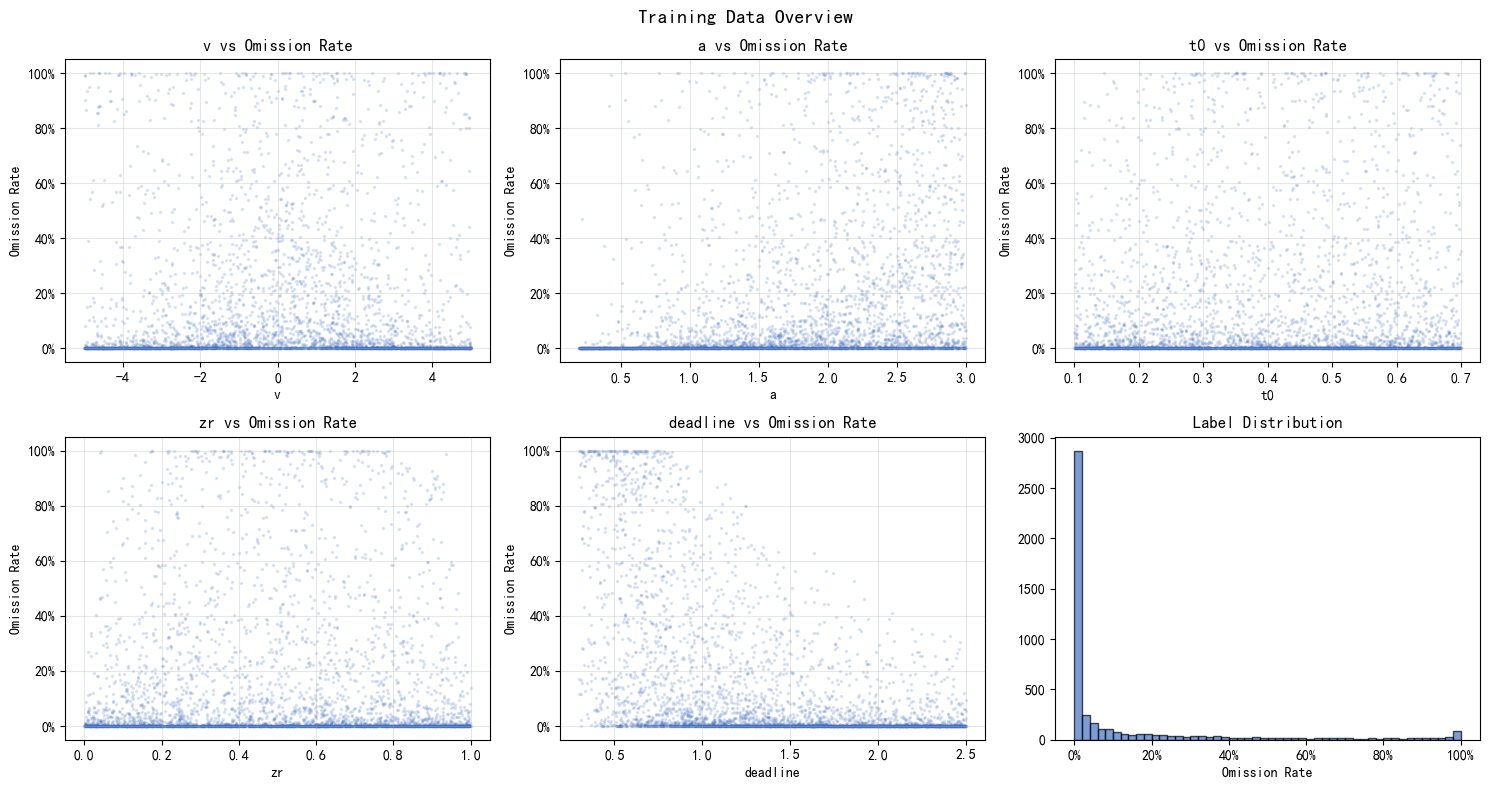

Stats: n=4699, mean=0.127, std=0.248, range=[0.000,1.000]


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
names = ["v", "a", "t0", "zr", "deadline"]
for i in range(5):
    ax = axes[i]
    ax.scatter(X_raw[:, i], y_raw, alpha=0.15, s=2, c="#4472C4")
    ax.set_xlabel(names[i])
    ax.set_ylabel("Omission Rate")
    ax.set_title(f"{names[i]} vs Omission Rate")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(alpha=0.3)
ax = axes[5]
ax.hist(y_raw, bins=50, alpha=0.7, edgecolor="black", color="#4472C4")
ax.set_xlabel("Omission Rate")
ax.set_title("Label Distribution")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
fig.suptitle("Training Data Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Stats: n={X_raw.shape[0]}, mean={y_raw.mean():.3f}, std={y_raw.std():.3f}, range=[{y_raw.min():.3f},{y_raw.max():.3f}]")

---
## Step 4: Train/Test Split + Standardization

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=TEST_SIZE, random_state=SEED
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")

Train: 3759 | Test: 940 | Features: 5


---
## Step 5: Build & Train OPN (MLP)

Architecture: `Input(5) -> Dense(128,ReLU) -> Dense(64,ReLU) -> Dense(32,ReLU) -> Output(1)`

In [9]:
opn = MLPRegressor(
    hidden_layer_sizes=HIDDEN_LAYERS,
    activation="relu",
    solver="adam",
    alpha=ALPHA,
    batch_size=256,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=MAX_ITER,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=SEED,
    verbose=True,
)

t0 = time.perf_counter()
opn.fit(X_train, y_train)
train_time = time.perf_counter() - t0
print(f"Training done: {train_time:.1f}s, {opn.n_iter_} iters, loss={opn.loss_:.6f}")

Iteration 1, loss = 0.04113945
Validation score: 0.284273
Iteration 2, loss = 0.02069870
Validation score: 0.475133
Iteration 3, loss = 0.01438090
Validation score: 0.614784
Iteration 4, loss = 0.01063910
Validation score: 0.714592
Iteration 5, loss = 0.00800267
Validation score: 0.784606
Iteration 6, loss = 0.00640702
Validation score: 0.832804
Iteration 7, loss = 0.00564767
Validation score: 0.841957
Iteration 8, loss = 0.00506850
Validation score: 0.871172
Iteration 9, loss = 0.00452057
Validation score: 0.879390
Iteration 10, loss = 0.00436403
Validation score: 0.893007
Iteration 11, loss = 0.00397408
Validation score: 0.899589
Iteration 12, loss = 0.00377831
Validation score: 0.907174
Iteration 13, loss = 0.00359762
Validation score: 0.907945
Iteration 14, loss = 0.00340571
Validation score: 0.913359
Iteration 15, loss = 0.00326443
Validation score: 0.918751
Iteration 16, loss = 0.00311242
Validation score: 0.923728
Iteration 17, loss = 0.00299850
Validation score: 0.928138
Iterat

### Loss curve

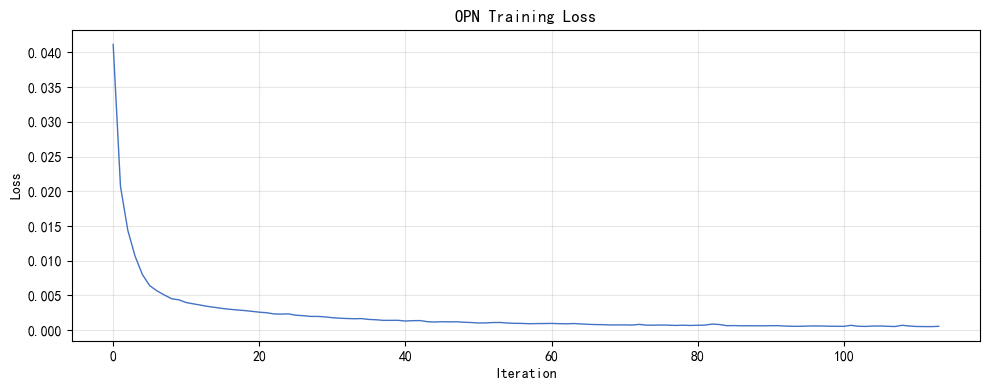

In [10]:
if hasattr(opn, "loss_curve_"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(opn.loss_curve_, "#4472C4", linewidth=1)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("OPN Training Loss", fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Step 6: Evaluate

In [11]:
y_train_pred = opn.predict(X_train)
y_test_pred  = opn.predict(X_test)

train_r2  = opn.score(X_train, y_train)
test_r2   = opn.score(X_test, y_test)
train_mae = float(np.mean(np.abs(y_train - y_train_pred)))
test_mae  = float(np.mean(np.abs(y_test - y_test_pred)))
train_rmse = float(np.sqrt(np.mean((y_train - y_train_pred) ** 2)))
test_rmse  = float(np.sqrt(np.mean((y_test - y_test_pred) ** 2)))

print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
print("-" * 30)
print(f"{'R2':<8} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'MAE':<8} {train_mae:>10.4f} {test_mae:>10.4f}")
print(f"{'RMSE':<8} {train_rmse:>10.4f} {test_rmse:>10.4f}")

if test_r2 >= 0.90:
    print(f"R2={test_r2:.3f} >= 0.90 - Excellent")
elif test_r2 >= 0.85:
    print(f"R2={test_r2:.3f} >= 0.85 - Acceptable")
else:
    print(f"R2={test_r2:.3f} < 0.85 - Consider more data / deeper network")

Metric        Train       Test
------------------------------
R2           0.9906     0.9860
MAE          0.0141     0.0166
RMSE         0.0243     0.0282
R2=0.986 >= 0.90 - Excellent


### Demo: predict omission rate for specific DDM params

In [12]:
test_params = np.array([
    [1.5, 1.2, 0.3, 0.5, 0.63],   # G2-like
    [1.49, 1.48, 0.40, 0.45, 1.20], # G5-like
    [0.92, 1.37, 0.66, 0.71, 2.00], # G6-like
])
preds = np.clip(opn.predict(scaler.transform(test_params)), 1e-10, 1-1e-10)
for label, p in zip(["G2 (d=0.63s)", "G5 (d=1.20s)", "G6 (d=2.00s)"], preds):
    print(f"{label}: {p:.3f} ({p*100:.1f}%)")

G2 (d=0.63s): 0.332 (33.2%)
G5 (d=1.20s): 0.110 (11.0%)
G6 (d=2.00s): 0.011 (1.1%)


---
## Step 7: Visual Diagnostics

### 7a: True vs Predicted + Residuals

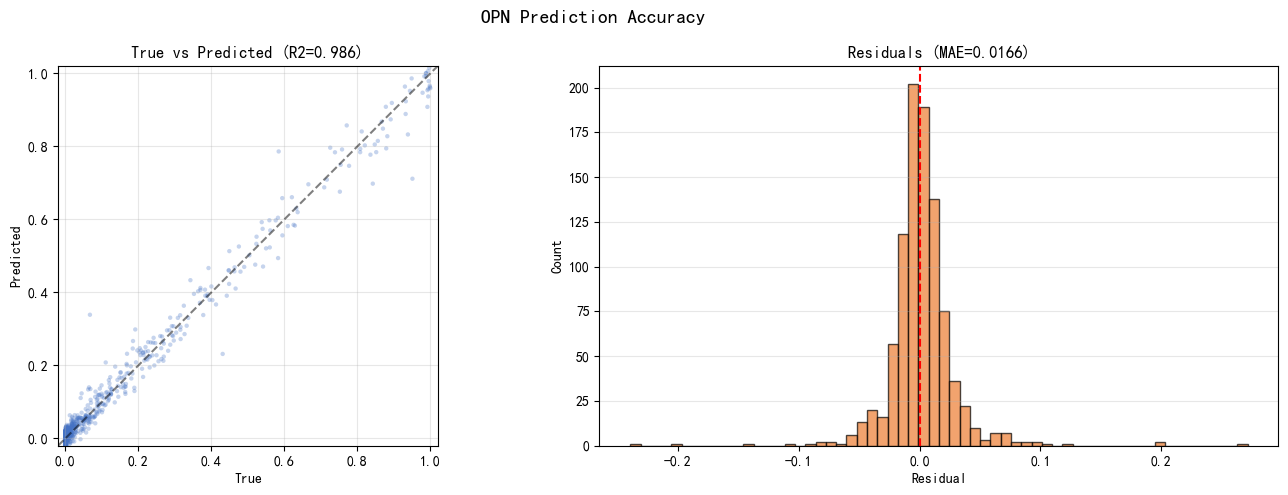

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(y_test, y_test_pred, alpha=0.3, s=10, c="#4472C4", edgecolors="none")
lims = [-0.02, 1.02]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True"); ax.set_ylabel("Predicted")
ax.set_title(f"True vs Predicted (R2={test_r2:.3f})", fontweight="bold")
ax.set_aspect("equal"); ax.grid(alpha=0.3)

ax = axes[1]
residuals = y_test_pred - y_test
ax.hist(residuals, bins=60, alpha=0.7, edgecolor="black", color="#ED7D31")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual"); ax.set_ylabel("Count")
ax.set_title(f"Residuals (MAE={test_mae:.4f})", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
fig.suptitle("OPN Prediction Accuracy", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "opn_prediction_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

### 7b: Marginal Effects (how each parameter affects omission rate)

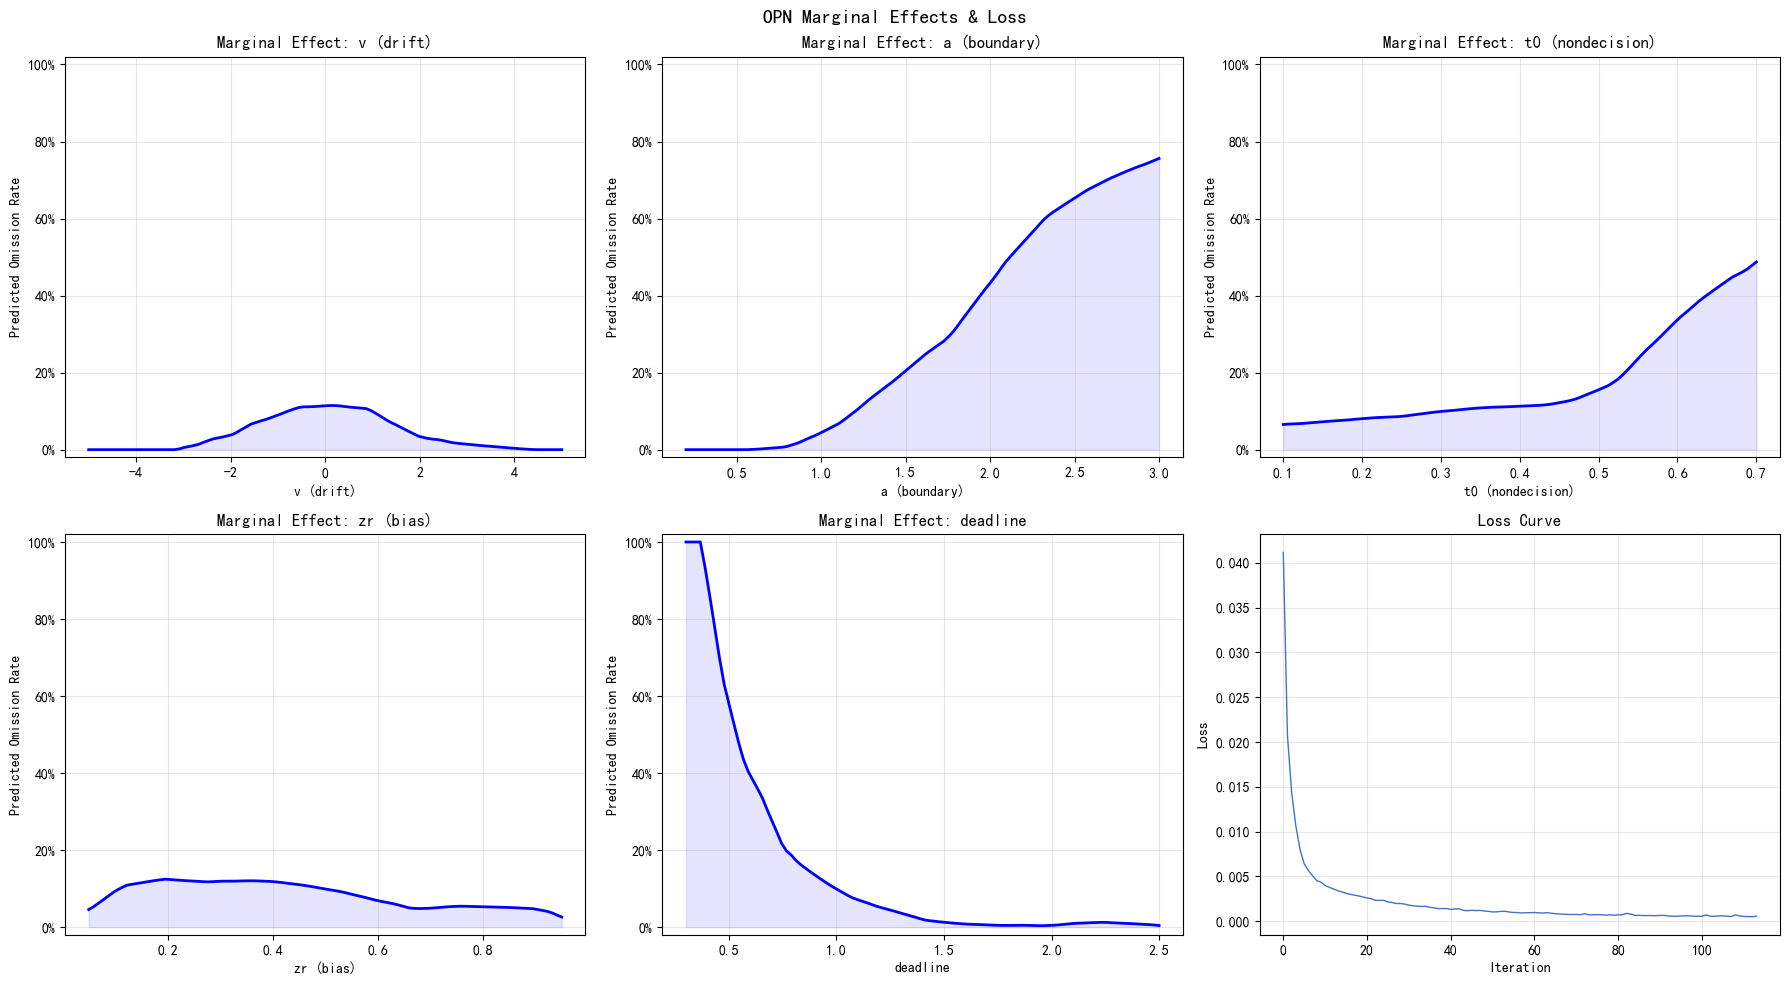

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fixed = np.array([1.0, 1.2, 0.3, 0.5, 1.0])
names = ["v (drift)", "a (boundary)", "t0 (nondecision)", "zr (bias)", "deadline"]
ranges = [(-5, 5), (0.2, 3.0), (0.1, 0.7), (0.05, 0.95), (0.3, 2.5)]
for i in range(5):
    ax = axes[i]
    lo, hi = ranges[i]
    fv = np.linspace(lo, hi, 100)
    Xe = np.tile(fixed, (100, 1)); Xe[:, i] = fv
    p = np.clip(opn.predict(scaler.transform(Xe)), 0, 1)
    ax.plot(fv, p, "b-", linewidth=2)
    ax.fill_between(fv, 0, p, alpha=0.1, color="blue")
    ax.set_xlabel(names[i]); ax.set_ylabel("Predicted Omission Rate")
    ax.set_title(f"Marginal Effect: {names[i]}", fontweight="bold")
    ax.set_ylim(-0.02, 1.02); ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(alpha=0.3)
ax = axes[5]
if hasattr(opn, "loss_curve_"):
    ax.plot(opn.loss_curve_, "#4472C4", linewidth=1)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Loss")
    ax.set_title("Loss Curve", fontweight="bold"); ax.grid(alpha=0.3)
fig.suptitle("OPN Marginal Effects & Loss", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "opn_marginal_effects.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Step 8: Save Model

In [15]:
import joblib

metrics = {
    "train_r2": float(train_r2), "test_r2": float(test_r2),
    "train_mae": train_mae, "test_mae": test_mae,
    "train_rmse": train_rmse, "test_rmse": test_rmse,
    "train_time_s": round(train_time, 1),
    "train_n": int(X_train.shape[0]), "test_n": int(X_test.shape[0]),
    "n_features": int(X_train.shape[1]),
    "hidden_layers": list(HIDDEN_LAYERS),
    "mode": TRAIN_MODE, "timestamp": datetime.now().isoformat(),
}

joblib.dump(opn, DATA_DIR / "opn_model.joblib")
joblib.dump(scaler, DATA_DIR / "opn_scaler.joblib")
with open(DATA_DIR / "opn_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f"Model saved to: {DATA_DIR}")
print(f"  opn_model.joblib, opn_scaler.joblib, opn_metrics.json")

Model saved to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\OPN_Training
  opn_model.joblib, opn_scaler.joblib, opn_metrics.json


### Verify: load and predict

In [16]:
opn2 = joblib.load(DATA_DIR / "opn_model.joblib")
sc2 = joblib.load(DATA_DIR / "opn_scaler.joblib")
p = np.clip(opn2.predict(sc2.transform(np.array([[2.0, 1.0, 0.25, 0.5, 1.0]])))[0], 1e-10, 1-1e-10)
print(f"Load test: (v=2,a=1,t0=0.25,zr=0.5,d=1.0) -> omission_rate={p:.4f}")
print("Save/Load OK")

Load test: (v=2,a=1,t0=0.25,zr=0.5,d=1.0) -> omission_rate=0.0193
Save/Load OK


---
## Summary & Next Steps

| Step | Output |
|:---|:---|
| 3 | `2_Data/Generate_Data/OPN_Training/opn_training_data_{suffix}.npz` |
| 5 | `opn` (MLPRegressor trained model) |
| 6 | R2, MAE, RMSE metrics |
| 7 | `3_Figures/OPN_Training/opn_*.png` |
| 8 | `opn_model.joblib`, `opn_scaler.joblib`, `opn_metrics.json` |

To use OPN in PyMC:
```python
opn = joblib.load("opn_model.joblib")
scaler = joblib.load("opn_scaler.joblib")

def opn_logp(v, a, t0, zr, deadline):
    X = scaler.transform(np.column_stack([v, a, t0, zr, deadline]))
    p = np.clip(opn.predict(X), 1e-10, 1-1e-10)
    return np.log(p)
```

See `5_Reference/Omission_LAN_OPN_实施作战计划.md` for full PyMC integration.